# Model evaluation

This notebook analyzes model-development experiments generated with:

```bash
python -m scripts.run_experiments --experiment <experiment_name>
```


In [128]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.base import clone
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.preprocessing import LabelEncoder

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)


## Setup


In [129]:
def find_project_root() -> Path:
    cwd = Path.cwd().resolve()

    for candidate in [cwd, *cwd.parents]:
        if (candidate / "src").exists() and (candidate / "notebooks").exists():
            return candidate

    raise FileNotFoundError(
        "Could not locate the project root. "
        "Run the notebook from inside the repository."
    )


PROJECT_ROOT = find_project_root()
RESULTS_DIR = PROJECT_ROOT / "results"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.evaluation import expanding_window_splits, split_development_holdout
from src.experiments import get_feature_columns
from src.models import build_logistic_regression, build_xgboost

PROJECT_ROOT, RESULTS_DIR


(PosixPath('/home/adrian/Proyectos/gas-sensor-drift-classification'),
 PosixPath('/home/adrian/Proyectos/gas-sensor-drift-classification/results'))

## Analysis helpers

In [130]:
REQUIRED_COLUMNS = {
    "model",
    "protocol",
    "split",
    "macro_f1",
    "accuracy",
}


def load_experiment(filename: str) -> pd.DataFrame:
    path = RESULTS_DIR / filename
    results = pd.read_csv(path)

    missing_columns = REQUIRED_COLUMNS - set(results.columns)
    if missing_columns:
        raise ValueError(
            f"{filename} is missing required columns: "
            f"{sorted(missing_columns)}"
        )

    print(f"Loaded: {path.name}")
    print(f"Rows: {len(results):,}")
    print(f"Models: {results['model'].nunique()}")
    print(f"Protocols: {sorted(results['protocol'].unique())}")

    return results


def class_f1_columns(df: pd.DataFrame) -> list[str]:
    columns = [
        column
        for column in df.columns
        if column.startswith("f1_class_")
    ]

    return sorted(
        columns,
        key=lambda column: int(
            column.rsplit("_", maxsplit=1)[1]
        ),
    )


def protocol_results(
    df: pd.DataFrame,
    protocol: str,
) -> pd.DataFrame:
    return df.loc[df["protocol"] == protocol].copy()


In [131]:
def summarize_random_cv(
    results: pd.DataFrame,
) -> pd.DataFrame:
    random_results = protocol_results(
        results,
        "random_stratified",
    )

    return (
        random_results
        .groupby("model")[["macro_f1", "accuracy"]]
        .agg(["mean", "std"])
    )


def summarize_random_class_f1(
    results: pd.DataFrame,
) -> pd.DataFrame:
    random_results = protocol_results(
        results,
        "random_stratified",
    )

    class_columns = class_f1_columns(results)

    return (
        random_results
        .groupby("model")[class_columns]
        .mean()
    )


def get_temporal_results(
    results: pd.DataFrame,
) -> pd.DataFrame:
    temporal = protocol_results(
        results,
        "expanding_window",
    )

    return temporal.sort_values(
        ["model", "validation_batch"]
    )


In [132]:
def temporal_summary(
    results: pd.DataFrame,
) -> pd.DataFrame:
    temporal = get_temporal_results(results)

    return (
        temporal
        .groupby("model")["macro_f1"]
        .agg(
            mean="mean",
            std="std",
            minimum="min",
            maximum="max",
        )
        .sort_values("mean", ascending=False)
    )


def random_vs_temporal_summary(
    results: pd.DataFrame,
) -> pd.DataFrame:
    random_results = protocol_results(
        results,
        "random_stratified",
    )
    temporal = get_temporal_results(results)

    random_means = (
        random_results
        .groupby("model", as_index=False)["macro_f1"]
        .mean()
        .rename(
            columns={
                "macro_f1": "random_cv_macro_f1_mean"
            }
        )
    )

    temporal_stats = (
        temporal
        .groupby("model")["macro_f1"]
        .agg(
            temporal_macro_f1_mean="mean",
            temporal_macro_f1_std="std",
            temporal_macro_f1_min="min",
            temporal_macro_f1_max="max",
        )
        .reset_index()
    )

    return random_means.merge(
        temporal_stats,
        on="model",
        how="outer",
    )


In [133]:
def plot_temporal_macro_f1(
    results: pd.DataFrame,
    title: str,
) -> None:
    temporal = get_temporal_results(results)

    fig, ax = plt.subplots(figsize=(9, 5))

    for model_name, model_results in temporal.groupby("model"):
        ax.plot(
            model_results["validation_batch"],
            model_results["macro_f1"],
            marker="o",
            label=model_name,
        )

    ax.set_xlabel("Validation batch")
    ax.set_ylabel("Macro-F1")
    ax.set_title(title)
    ax.set_ylim(0.0, 1.05)
    ax.grid(alpha=0.25)
    ax.legend()

    plt.show()


def plot_temporal_class_f1(
    results: pd.DataFrame,
) -> None:
    temporal = get_temporal_results(results)
    class_columns = class_f1_columns(results)

    for model_name, model_results in temporal.groupby("model"):
        fig, ax = plt.subplots(figsize=(10, 5))

        for column in class_columns:
            class_label = column.rsplit("_", maxsplit=1)[1]

            ax.plot(
                model_results["validation_batch"],
                model_results[column],
                marker="o",
                label=f"class {class_label}",
            )

        ax.set_xlabel("Validation batch")
        ax.set_ylabel("F1")
        ax.set_title(
            f"Per-class temporal F1 ({model_name})"
        )
        ax.set_ylim(0.0, 1.05)
        ax.grid(alpha=0.25)
        ax.legend(ncol=3)

        plt.show()


In [134]:
def metric_gap_table(
    results: pd.DataFrame,
) -> pd.DataFrame:
    temporal = get_temporal_results(results)

    gap = temporal[
        [
            "model",
            "validation_batch",
            "macro_f1",
            "accuracy",
        ]
    ].copy()

    gap["accuracy_minus_macro_f1"] = (
        gap["accuracy"] - gap["macro_f1"]
    )

    return gap.sort_values(
        ["model", "accuracy_minus_macro_f1"],
        ascending=[True, False],
    )


In [135]:
def collect_temporal_predictions(
    data: pd.DataFrame,
    model,
) -> pd.DataFrame:
    """Recreate expanding-window predictions for one model."""
    feature_columns = get_feature_columns(data)
    predictions_by_batch = []

    for split in expanding_window_splits(data):
        train = data.iloc[split.train_indices]
        validation = data.iloc[split.validation_indices]
        label_encoder = LabelEncoder()
        y_train = label_encoder.fit_transform(train["label"])

        fitted_model = clone(model)
        fitted_model.fit(train[feature_columns], y_train)
        encoded_predictions = fitted_model.predict(
            validation[feature_columns]
        )

        predictions_by_batch.append(
            pd.DataFrame(
                {
                    "validation_batch": validation["batch"].to_numpy(),
                    "actual": validation["label"].to_numpy(),
                    "predicted": label_encoder.inverse_transform(
                        encoded_predictions.astype(int)
                    ),
                }
            )
        )

    return pd.concat(predictions_by_batch, ignore_index=True)


def confusion_matrix_table(
    predictions: pd.DataFrame,
    labels: tuple[int, ...],
) -> pd.DataFrame:
    """Return raw temporal-validation counts by actual and predicted class."""
    matrix = confusion_matrix(
        predictions["actual"],
        predictions["predicted"],
        labels=labels,
    )

    return pd.DataFrame(
        matrix,
        index=pd.Index(labels, name="Actual class"),
        columns=pd.Index(labels, name="Predicted class"),
    )


def plot_temporal_confusion_matrices(
    predictions_by_model: dict[str, pd.DataFrame],
    labels: tuple[int, ...],
) -> None:
    """Plot row-normalized confusion matrices for temporal validation."""
    fig, axes = plt.subplots(
        1,
        len(predictions_by_model),
        figsize=(6 * len(predictions_by_model), 5),
        squeeze=False,
        layout="constrained",
    )
    displays = []

    for ax, (model_name, predictions) in zip(
        axes.ravel(),
        predictions_by_model.items(),
    ):
        matrix = confusion_matrix(
            predictions["actual"],
            predictions["predicted"],
            labels=labels,
            normalize="true",
        )
        display = ConfusionMatrixDisplay(
            confusion_matrix=matrix,
            display_labels=labels,
        )
        display.plot(
            ax=ax,
            cmap="Blues",
            colorbar=False,
            values_format=".2f",
        )
        ax.set_title(model_name)
        ax.set_xlabel("Predicted class")
        ax.set_ylabel("Actual class")
        displays.append(display)

    fig.colorbar(
        displays[0].im_,
        ax=axes.ravel().tolist(),
        label="Proportion within actual class",
        location="right",
        pad=0.02,
    )
    fig.suptitle("Temporal validation confusion matrices")
    plt.show()


# Experiment 1: Logistic Regression regularization

`C=1.0` is the original untuned baseline. The remaining configurations test whether stronger or weaker L2 regularization improves generalization to future acquisition batches.

In [98]:
logreg_results = load_experiment(
    "logreg_tuning.csv"
)

logreg_results.head()


Loaded: logreg_tuning.csv
Rows: 52
Models: 4
Protocols: ['expanding_window', 'random_stratified']


,model,protocol,split,train_batches,validation_batches,validation_batch,n_train,n_validation,macro_f1,accuracy,f1_class_1,f1_class_2,f1_class_3,f1_class_4,f1_class_5,f1_class_6
0,logreg_C0.01,random_stratified,random_fold_1,"(np.int64(1), np.int64(2), np.int64(3), np.int...","(np.int64(1), np.int64(2), np.int64(3), np.int...",NaN,8248,2062,0.969046,0.972842,0.972903,0.992465,0.977995,0.930582,0.983471,0.956863
1,logreg_C0.01,random_stratified,random_fold_2,"(np.int64(1), np.int64(2), np.int64(3), np.int...","(np.int64(1), np.int64(2), np.int64(3), np.int...",NaN,8248,2062,0.978142,0.980601,0.976923,0.996778,0.985437,0.951128,0.986584,0.972000
2,logreg_C0.01,random_stratified,random_fold_3,"(np.int64(1), np.int64(2), np.int64(3), np.int...","(np.int64(1), np.int64(2), np.int64(3), np.int...",NaN,8248,2062,0.974493,0.977207,0.975547,0.990333,0.970588,0.955720,0.984359,0.970414
3,logreg_C0.01,random_stratified,random_fold_4,"(np.int64(1), np.int64(2), np.int64(3), np.int...","(np.int64(1), np.int64(2), np.int64(3), np.int...",NaN,8248,2062,0.967528,0.971872,0.969309,0.989270,0.962594,0.950943,0.985477,0.947573
4,logreg_C0.01,random_stratified,random_fold_5,"(np.int64(1), np.int64(2), np.int64(3), np.int...","(np.int64(1), np.int64(2), np.int64(3), np.int...",NaN,8248,2062,0.970192,0.973327,0.974026,0.988260,0.965517,0.947368,0.979381,0.966601


## Random stratified evaluation

This remains a conventional IID-like reference. Because acquisition batches are mixed across folds, it should not be treated as a deployment-like estimate under temporal distribution shift.


In [99]:
random_logreg = protocol_results(
    logreg_results,
    "random_stratified",
)

random_logreg[
    ["model", "split", "macro_f1", "accuracy"]
].sort_values(["model", "split"])


,model,split,macro_f1,accuracy
0,logreg_C0.01,random_fold_1,0.969046,0.972842
1,logreg_C0.01,random_fold_2,0.978142,0.980601
2,logreg_C0.01,random_fold_3,0.974493,0.977207
3,logreg_C0.01,random_fold_4,0.967528,0.971872
4,logreg_C0.01,random_fold_5,0.970192,0.973327
13,logreg_C0.1,random_fold_1,0.986597,0.987876
14,logreg_C0.1,random_fold_2,0.986702,0.988361
15,logreg_C0.1,random_fold_3,0.985465,0.986906
16,logreg_C0.1,random_fold_4,0.983282,0.983996
17,logreg_C0.1,random_fold_5,0.982976,0.984481


In [100]:
summarize_random_cv(logreg_results)


macro_f1            accuracy          
                  mean       std      mean       std
model                                               
logreg_C0.01  0.971880  0.004355  0.975170  0.003652
logreg_C0.1   0.985004  0.001783  0.986324  0.001982
logreg_C1     0.990061  0.003965  0.991077  0.003474
logreg_C10    0.991382  0.002665  0.992241  0.002169

### Mean per-class F1 under random stratified CV


In [101]:
summarize_random_class_f1(logreg_results)


,f1_class_1,f1_class_2,f1_class_3,f1_class_4,f1_class_5,f1_class_6
model,,,,,,
logreg_C0.01,0.973742,0.991421,0.972426,0.947148,0.983855,0.962690
logreg_C0.1,0.985378,0.991855,0.975996,0.981472,0.988610,0.986715
logreg_C1,0.993623,0.995065,0.978194,0.992505,0.989851,0.991129
logreg_C10,0.994657,0.995917,0.979670,0.993223,0.990493,0.994335


## Expanding-window temporal evaluation

For every validation batch, training is restricted to earlier batches. The individual batch results remain the primary evidence because batch sizes and class composition differ substantially.


In [102]:
logreg_temporal = get_temporal_results(
    logreg_results
)

temporal_columns = [
    "model",
    "validation_batch",
    "n_validation",
    "macro_f1",
    "accuracy",
    *class_f1_columns(logreg_results),
]

logreg_temporal[temporal_columns]


,model,validation_batch,n_validation,macro_f1,accuracy,f1_class_1,f1_class_2,f1_class_3,f1_class_4,f1_class_5,f1_class_6
5,logreg_C0.01,2.0,1244,0.632895,0.825563,0.590818,0.977376,0.990099,0.000000,0.916497,0.322581
6,logreg_C0.01,3.0,1586,0.783148,0.800126,0.388119,0.998981,0.981567,0.580282,0.966790,NaN
7,logreg_C0.01,4.0,161,0.791339,0.795031,0.816667,0.926829,1.000000,0.723404,0.489796,NaN
8,logreg_C0.01,5.0,197,0.980111,0.979695,0.982456,1.000000,0.974359,0.967742,0.976000,NaN
9,logreg_C0.01,6.0,2300,0.667291,0.773043,0.974104,0.999130,0.957346,0.103020,0.970149,0.000000
10,logreg_C0.01,7.0,3613,0.818254,0.821478,0.987072,0.788783,0.944282,0.429926,0.820915,0.938547
11,logreg_C0.01,8.0,294,0.760593,0.690476,0.952381,0.947368,0.805970,0.911765,0.628319,0.317757
12,logreg_C0.01,9.0,470,0.753997,0.770213,0.968254,1.000000,1.000000,0.589641,0.946667,0.019417
18,logreg_C0.1,2.0,1244,0.698311,0.846463,0.623482,0.968326,0.990099,0.000000,0.941294,0.666667
19,logreg_C0.1,3.0,1586,0.795698,0.814628,0.394904,0.996948,0.986239,0.618919,0.981481,NaN


### Temporal macro-F1 by batch


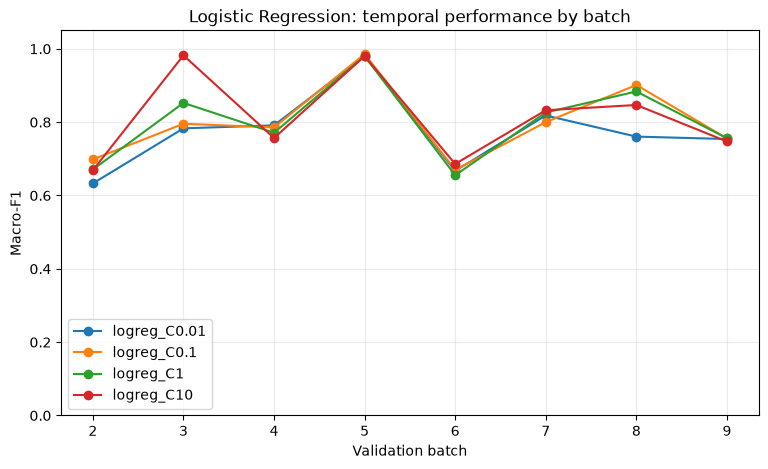

In [103]:
plot_temporal_macro_f1(
    logreg_results,
    title="Logistic Regression: temporal performance by batch",
)


### Descriptive temporal summary

The unweighted mean treats every acquisition period equally. It is useful as a compact secondary summary, but it does not replace the batch-by-batch results above.


In [104]:
temporal_summary(logreg_results)


,mean,std,minimum,maximum
model,,,,
logreg_C10,0.812587,0.120967,0.668881,0.982189
logreg_C1,0.799547,0.109047,0.655378,0.980111
logreg_C0.1,0.799046,0.103019,0.669810,0.985816
logreg_C0.01,0.773454,0.104676,0.632895,0.980111


### Accuracy vs macro-F1

A large difference can reveal uneven class-level performance in batches with imbalanced class composition.


In [105]:
metric_gap_table(logreg_results)


,model,validation_batch,macro_f1,accuracy,accuracy_minus_macro_f1
5,logreg_C0.01,2.0,0.632895,0.825563,0.192668
9,logreg_C0.01,6.0,0.667291,0.773043,0.105752
6,logreg_C0.01,3.0,0.783148,0.800126,0.016979
12,logreg_C0.01,9.0,0.753997,0.770213,0.016216
7,logreg_C0.01,4.0,0.791339,0.795031,0.003692
10,logreg_C0.01,7.0,0.818254,0.821478,0.003224
8,logreg_C0.01,5.0,0.980111,0.979695,-0.000416
11,logreg_C0.01,8.0,0.760593,0.690476,-0.070117
18,logreg_C0.1,2.0,0.698311,0.846463,0.148152
22,logreg_C0.1,6.0,0.669810,0.780435,0.110625


## Per-class temporal performance

Absent classes remain `NaN`; this is intentionally different from assigning F1 = 0.


In [106]:
logreg_temporal[
    [
        "model",
        "validation_batch",
        *class_f1_columns(logreg_results),
    ]
]


,model,validation_batch,f1_class_1,f1_class_2,f1_class_3,f1_class_4,f1_class_5,f1_class_6
5,logreg_C0.01,2.0,0.590818,0.977376,0.990099,0.000000,0.916497,0.322581
6,logreg_C0.01,3.0,0.388119,0.998981,0.981567,0.580282,0.966790,NaN
7,logreg_C0.01,4.0,0.816667,0.926829,1.000000,0.723404,0.489796,NaN
8,logreg_C0.01,5.0,0.982456,1.000000,0.974359,0.967742,0.976000,NaN
9,logreg_C0.01,6.0,0.974104,0.999130,0.957346,0.103020,0.970149,0.000000
10,logreg_C0.01,7.0,0.987072,0.788783,0.944282,0.429926,0.820915,0.938547
11,logreg_C0.01,8.0,0.952381,0.947368,0.805970,0.911765,0.628319,0.317757
12,logreg_C0.01,9.0,0.968254,1.000000,1.000000,0.589641,0.946667,0.019417
18,logreg_C0.1,2.0,0.623482,0.968326,0.990099,0.000000,0.941294,0.666667
19,logreg_C0.1,3.0,0.394904,0.996948,0.986239,0.618919,0.981481,NaN


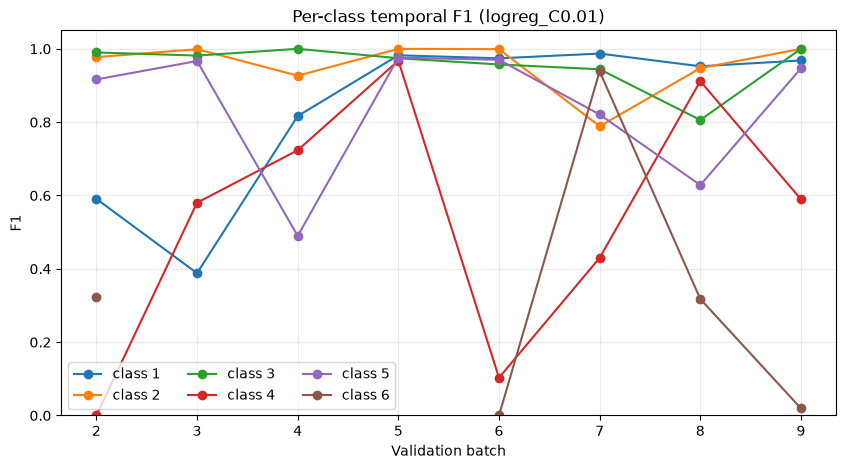

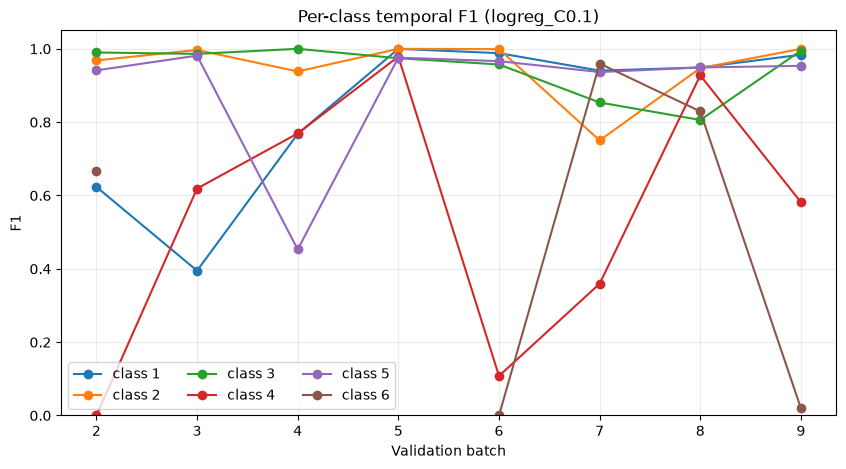

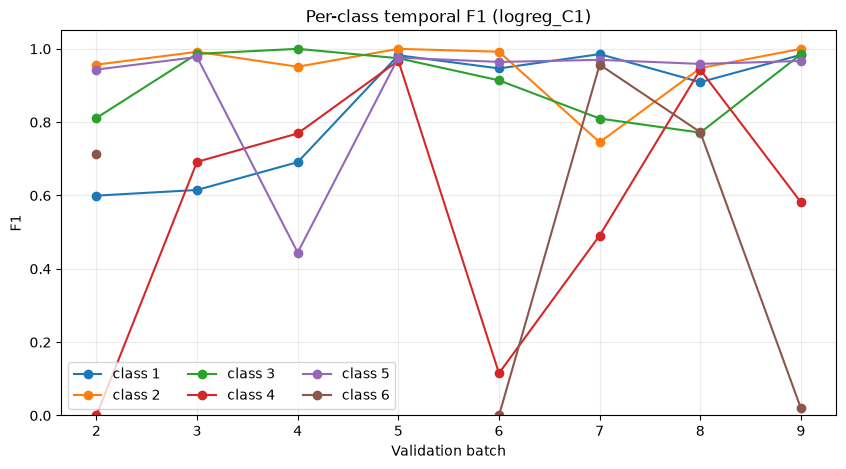

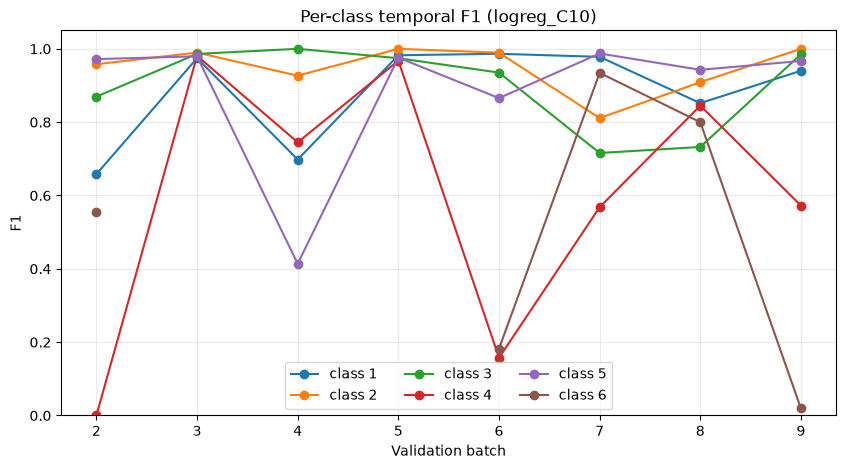

In [107]:
plot_temporal_class_f1(
    logreg_results
)


## Random vs temporal evaluation


In [108]:
random_vs_temporal_summary(
    logreg_results
)


,model,random_cv_macro_f1_mean,temporal_macro_f1_mean,temporal_macro_f1_std,temporal_macro_f1_min,temporal_macro_f1_max
0,logreg_C0.01,0.971880,0.773454,0.104676,0.632895,0.980111
1,logreg_C0.1,0.985004,0.799046,0.103019,0.669810,0.985816
2,logreg_C1,0.990061,0.799547,0.109047,0.655378,0.980111
3,logreg_C10,0.991382,0.812587,0.120967,0.668881,0.982189


Increasing C generally improves Logistic Regression performance, although the effect is substantially smaller than the variation observed across acquisition batches. C=10 achieves the highest mean temporal macro-F1 (0.813), compared with 0.800 for the original C=1 baseline, while maintaining a similar worst-batch performance. However, it also exhibits greater variability across batches and does not consistently outperform the other configurations in every period. We therefore select C=10 as the Logistic Regression configuration for subsequent model comparison, while noting that regularization strength has a relatively modest effect compared with batch-dependent distribution shift.

Random stratified cross-validation consistently produces substantially higher performance estimates than the expanding-window evaluation. For all Logistic Regression configurations, random CV yields macro-F1 scores above 0.97, whereas mean temporal performance ranges from approximately 0.77 to 0.81 and varies considerably across acquisition batches. This large gap indicates that randomly mixing samples from different batches provides an overly optimistic estimate of performance when the objective is to generalize to future acquisition periods. The temporal protocol therefore provides the more relevant basis for model selection in this setting, while random cross-validation is retained as an IID-like reference.

# Experiment 2: XGBoost depth tuning

This experiment evaluates whether a nonlinear tree-based model improves robustness across acquisition batches.

The configurations differ only in `max_depth` (`2`, `4`, and `6`), while the remaining XGBoost hyperparameters are kept fixed. The objective is to study the effect of model complexity without performing an extensive hyperparameter search.

As in the Logistic Regression experiment, model selection is based primarily on expanding-window temporal evaluation, while random stratified cross-validation is retained as an IID-like reference.

In [109]:
xgboost_results = load_experiment(
    "xgboost_tuning.csv"
)

xgboost_results.head()

Loaded: xgboost_tuning.csv
Rows: 39
Models: 3
Protocols: ['expanding_window', 'random_stratified']


,model,protocol,split,train_batches,validation_batches,validation_batch,n_train,n_validation,macro_f1,accuracy,f1_class_1,f1_class_2,f1_class_3,f1_class_4,f1_class_5,f1_class_6
0,xgboost_depth2,random_stratified,random_fold_1,"(np.int64(1), np.int64(2), np.int64(3), np.int...","(np.int64(1), np.int64(2), np.int64(3), np.int...",NaN,8248,2062,0.987190,0.988361,0.993647,0.995699,0.982968,0.977358,0.985567,0.987903
1,xgboost_depth2,random_stratified,random_fold_2,"(np.int64(1), np.int64(2), np.int64(3), np.int...","(np.int64(1), np.int64(2), np.int64(3), np.int...",NaN,8248,2062,0.991401,0.992241,0.988506,0.998924,0.987952,0.983302,0.993789,0.995935
2,xgboost_depth2,random_stratified,random_fold_3,"(np.int64(1), np.int64(2), np.int64(3), np.int...","(np.int64(1), np.int64(2), np.int64(3), np.int...",NaN,8248,2062,0.990059,0.991271,0.994911,0.992449,0.973621,0.990689,0.992731,0.995951
3,xgboost_depth2,random_stratified,random_fold_4,"(np.int64(1), np.int64(2), np.int64(3), np.int...","(np.int64(1), np.int64(2), np.int64(3), np.int...",NaN,8248,2062,0.990388,0.991271,0.992405,0.994652,0.987835,0.986817,0.992716,0.987903
4,xgboost_depth2,random_stratified,random_fold_5,"(np.int64(1), np.int64(2), np.int64(3), np.int...","(np.int64(1), np.int64(2), np.int64(3), np.int...",NaN,8248,2062,0.987370,0.988361,0.991083,0.995717,0.983051,0.982857,0.985537,0.985972


## Random stratified evaluation

In [110]:
random_xgboost = protocol_results(
    xgboost_results,
    "random_stratified",
)

random_xgboost[
    ["model", "split", "macro_f1", "accuracy"]
].sort_values(["model", "split"])

,model,split,macro_f1,accuracy
0,xgboost_depth2,random_fold_1,0.987190,0.988361
1,xgboost_depth2,random_fold_2,0.991401,0.992241
2,xgboost_depth2,random_fold_3,0.990059,0.991271
3,xgboost_depth2,random_fold_4,0.990388,0.991271
4,xgboost_depth2,random_fold_5,0.987370,0.988361
13,xgboost_depth4,random_fold_1,0.991419,0.992241
14,xgboost_depth4,random_fold_2,0.993881,0.994665
15,xgboost_depth4,random_fold_3,0.995191,0.995635
16,xgboost_depth4,random_fold_4,0.994829,0.995150
17,xgboost_depth4,random_fold_5,0.991697,0.991756


In [111]:
summarize_random_cv(
    xgboost_results
)

macro_f1            accuracy          
                    mean       std      mean       std
model                                                 
xgboost_depth2  0.989282  0.001894  0.990301  0.001815
xgboost_depth4  0.993403  0.001754  0.993889  0.001769
xgboost_depth6  0.993553  0.002106  0.994083  0.001952

### Mean per-class F1 under random stratified CV

In [112]:
summarize_random_class_f1(
    xgboost_results
)

,f1_class_1,f1_class_2,f1_class_3,f1_class_4,f1_class_5,f1_class_6
model,,,,,,
xgboost_depth2,0.992110,0.995488,0.983085,0.984205,0.990068,0.990733
xgboost_depth4,0.993383,0.996567,0.990305,0.991015,0.994414,0.994736
xgboost_depth6,0.994403,0.996780,0.989835,0.991757,0.994200,0.994342


## Expanding-window temporal evaluation

The temporal protocol evaluates each configuration on future acquisition batches using only earlier batches for training. As before, the individual batch results are treated as the primary evidence because acquisition periods differ in both size and class composition.

In [113]:
xgboost_temporal = get_temporal_results(
    xgboost_results
)

temporal_columns = [
    "model",
    "validation_batch",
    "n_validation",
    "macro_f1",
    "accuracy",
    *class_f1_columns(xgboost_results),
]

xgboost_temporal[
    temporal_columns
]

,model,validation_batch,n_validation,macro_f1,accuracy,f1_class_1,f1_class_2,f1_class_3,f1_class_4,f1_class_5,f1_class_6
5,xgboost_depth2,2.0,1244,0.625699,0.805466,0.550459,0.926966,0.530612,0.000000,0.976923,0.769231
6,xgboost_depth2,3.0,1586,0.899905,0.907945,0.840159,0.982949,0.903226,0.837022,0.936170,NaN
7,xgboost_depth2,4.0,161,0.716009,0.708075,0.641509,0.977273,0.909091,0.652174,0.400000,NaN
8,xgboost_depth2,5.0,197,0.942031,0.944162,0.888889,1.000000,0.947368,0.923077,0.950820,NaN
9,xgboost_depth2,6.0,2300,0.605494,0.670870,0.796137,0.898273,0.905830,0.079235,0.953488,0.000000
10,xgboost_depth2,7.0,3613,0.664003,0.708552,0.860743,0.859192,0.529876,0.307522,0.782216,0.644471
11,xgboost_depth2,8.0,294,0.744538,0.833333,0.965517,0.228571,0.666667,0.842105,0.931034,0.833333
12,xgboost_depth2,9.0,470,0.692124,0.700000,0.629213,1.000000,1.000000,0.556863,0.935897,0.030769
18,xgboost_depth4,2.0,1244,0.583398,0.800643,0.554745,0.925666,0.487500,0.000000,0.976923,0.555556
19,xgboost_depth4,3.0,1586,0.934661,0.940731,0.916877,0.981964,0.927184,0.911111,0.936170,NaN


### Temporal macro-F1 by batch

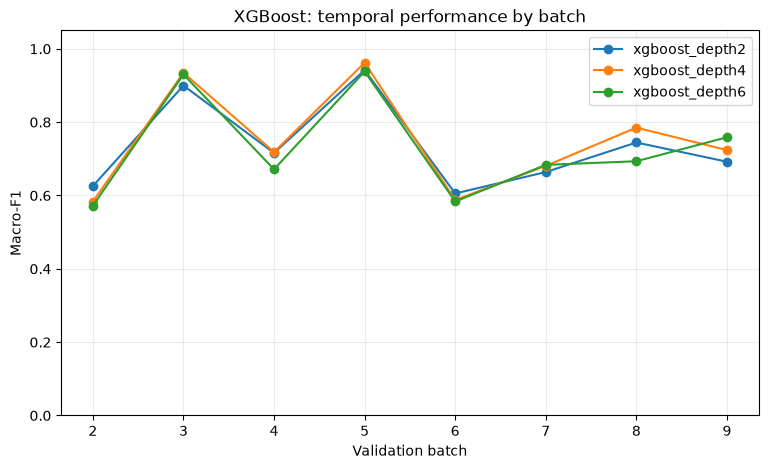

In [114]:
plot_temporal_macro_f1(
    xgboost_results,
    title="XGBoost: temporal performance by batch",
)

### Descriptive temporal summary

The unweighted mean gives equal importance to each acquisition period and is used only as a compact secondary summary. Model selection should also consider variability and batch-specific failures.

In [115]:
temporal_summary(
    xgboost_results
)

,mean,std,minimum,maximum
model,,,,
xgboost_depth4,0.747003,0.141831,0.583398,0.962100
xgboost_depth2,0.736225,0.123110,0.605494,0.942031
xgboost_depth6,0.728918,0.140142,0.572152,0.938197


### Accuracy vs macro-F1

In [116]:
metric_gap_table(
    xgboost_results
)

,model,validation_batch,macro_f1,accuracy,accuracy_minus_macro_f1
5,xgboost_depth2,2.0,0.625699,0.805466,0.179768
11,xgboost_depth2,8.0,0.744538,0.833333,0.088795
9,xgboost_depth2,6.0,0.605494,0.670870,0.065376
10,xgboost_depth2,7.0,0.664003,0.708552,0.044549
6,xgboost_depth2,3.0,0.899905,0.907945,0.008039
12,xgboost_depth2,9.0,0.692124,0.700000,0.007876
8,xgboost_depth2,5.0,0.942031,0.944162,0.002132
7,xgboost_depth2,4.0,0.716009,0.708075,-0.007935
18,xgboost_depth4,2.0,0.583398,0.800643,0.217245
24,xgboost_depth4,8.0,0.785141,0.867347,0.082206


## Per-class temporal performance

In [117]:
xgboost_temporal[
    [
        "model",
        "validation_batch",
        *class_f1_columns(xgboost_results),
    ]
]

,model,validation_batch,f1_class_1,f1_class_2,f1_class_3,f1_class_4,f1_class_5,f1_class_6
5,xgboost_depth2,2.0,0.550459,0.926966,0.530612,0.000000,0.976923,0.769231
6,xgboost_depth2,3.0,0.840159,0.982949,0.903226,0.837022,0.936170,NaN
7,xgboost_depth2,4.0,0.641509,0.977273,0.909091,0.652174,0.400000,NaN
8,xgboost_depth2,5.0,0.888889,1.000000,0.947368,0.923077,0.950820,NaN
9,xgboost_depth2,6.0,0.796137,0.898273,0.905830,0.079235,0.953488,0.000000
10,xgboost_depth2,7.0,0.860743,0.859192,0.529876,0.307522,0.782216,0.644471
11,xgboost_depth2,8.0,0.965517,0.228571,0.666667,0.842105,0.931034,0.833333
12,xgboost_depth2,9.0,0.629213,1.000000,1.000000,0.556863,0.935897,0.030769
18,xgboost_depth4,2.0,0.554745,0.925666,0.487500,0.000000,0.976923,0.555556
19,xgboost_depth4,3.0,0.916877,0.981964,0.927184,0.911111,0.936170,NaN


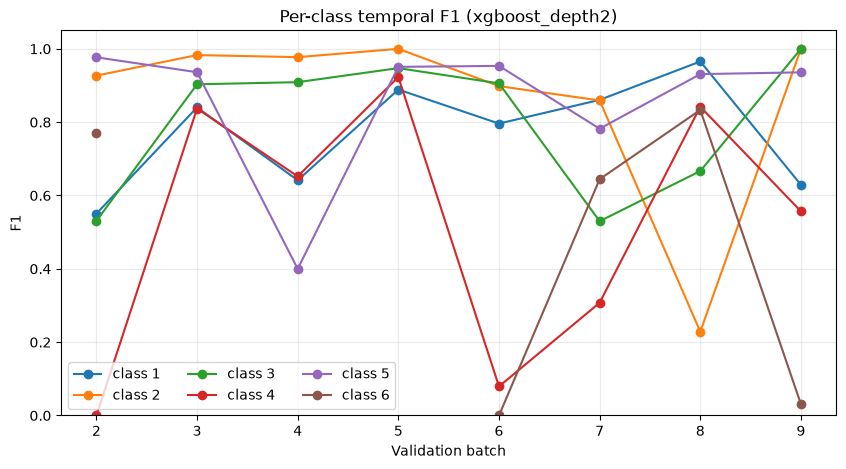

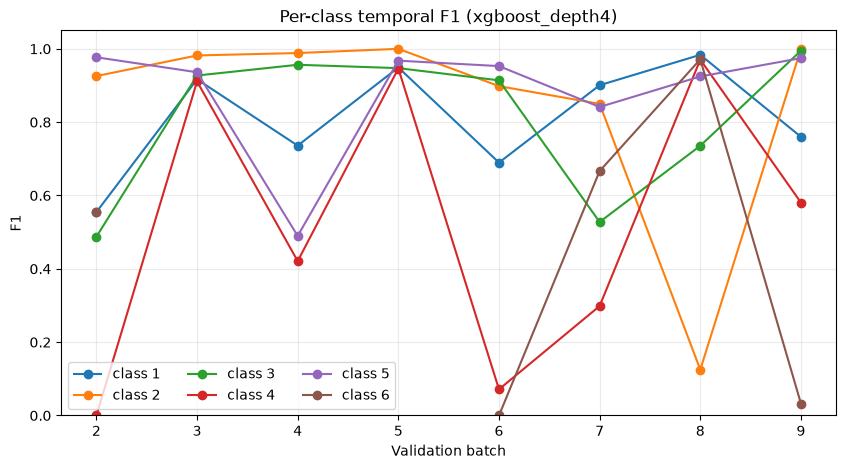

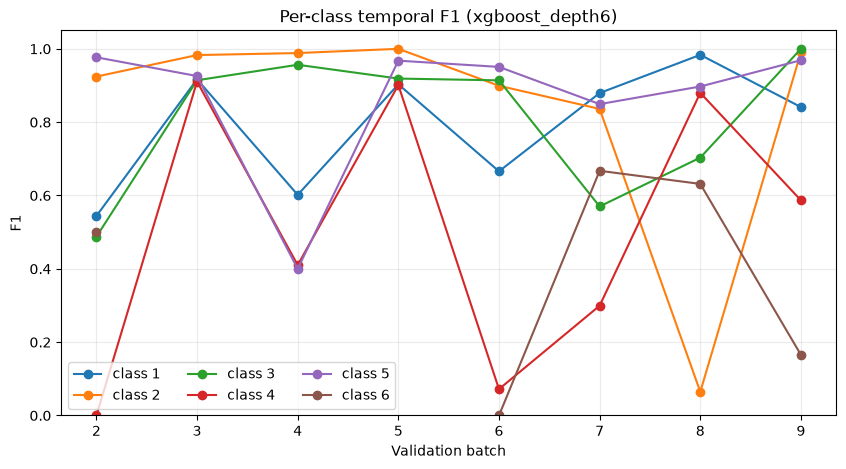

In [118]:
plot_temporal_class_f1(
    xgboost_results
)

## Random vs temporal evaluation

In [119]:
random_vs_temporal_summary(
    xgboost_results
)

,model,random_cv_macro_f1_mean,temporal_macro_f1_mean,temporal_macro_f1_std,temporal_macro_f1_min,temporal_macro_f1_max
0,xgboost_depth2,0.989282,0.736225,0.123110,0.605494,0.942031
1,xgboost_depth4,0.993403,0.747003,0.141831,0.583398,0.962100
2,xgboost_depth6,0.993553,0.728918,0.140142,0.572152,0.938197


In [120]:
logreg_selected = (
    logreg_results[
        logreg_results["model"] == "logreg_C10"
    ]
)

xgboost_summary = temporal_summary(
    xgboost_results
)

xgboost_summary

,mean,std,minimum,maximum
model,,,,
xgboost_depth4,0.747003,0.141831,0.583398,0.962100
xgboost_depth2,0.736225,0.123110,0.605494,0.942031
xgboost_depth6,0.728918,0.140142,0.572152,0.938197


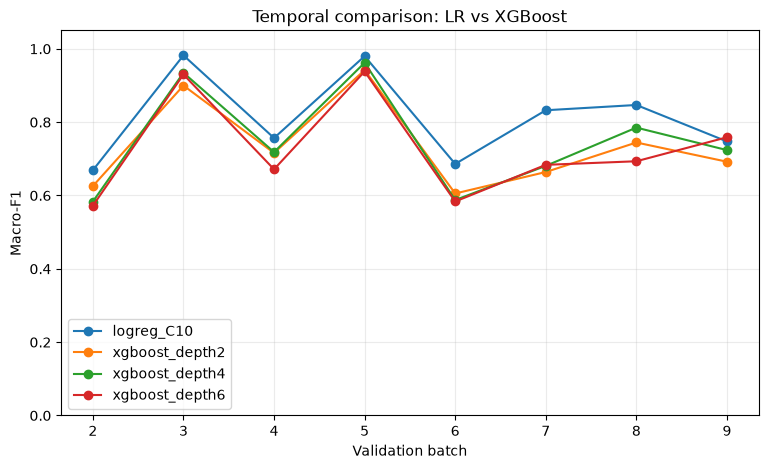

In [121]:
preliminary_comparison = pd.concat(
    [
        logreg_selected,
        xgboost_results,
    ],
    ignore_index=True,
)

plot_temporal_macro_f1(
    preliminary_comparison,
    title="Temporal comparison: LR vs XGBoost",
)

Increasing tree depth does not consistently improve generalization to unseen acquisition batches. While depths 4 and 6 achieve slightly higher random-CV performance than depth 2, depth 4 obtains the highest mean temporal macro-F1 (0.747), whereas increasing depth further reduces temporal performance to 0.729. The differences between depths are also considerably smaller than the variation observed across acquisition batches.

Despite achieving near-perfect performance under random stratified cross-validation, XGBoost generalizes substantially worse than the selected Logistic Regression model across future acquisition batches. The selected Logistic Regression configuration (C=10) achieves a mean temporal macro-F1 of 0.813, compared with 0.747 for XGBoost with max_depth=4, and outperforms the XGBoost variants in most validation batches. These results suggest that the additional nonlinear capacity of XGBoost improves performance when acquisition conditions are mixed across training and validation data, but does not translate into greater robustness to batch-dependent distribution shift.

## Confusion matrices

Each matrix pools the validation predictions from batches 2 to 9. Rows are normalized by the actual class: the diagonal is therefore class recall, and off-diagonal cells identify the classes that are confused. The raw-count tables retain the sample-volume context.


In [122]:
full_data = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "gas_sensor_drift.csv"
)
development_data, _ = split_development_holdout(full_data)
temporal_labels = tuple(sorted(development_data["label"].unique()))

selected_temporal_predictions = {
    "Logistic Regression (C=10)": collect_temporal_predictions(
        development_data,
        build_logistic_regression(C=10.0),
    ),
    "XGBoost (max_depth=4)": collect_temporal_predictions(
        development_data,
        build_xgboost(max_depth=4),
    ),
}

raw_temporal_confusion_matrices = {
    model_name: confusion_matrix_table(predictions, temporal_labels)
    for model_name, predictions in selected_temporal_predictions.items()
}

for model_name, matrix in raw_temporal_confusion_matrices.items():
    print(model_name)
    display(matrix)


Logistic Regression (C=10)


Predicted class,1,2,3,4,5,6
Actual class,,,,,,
1,1821,2,5,14,24,9
2,39,2176,6,1,6,0
3,20,37,873,0,27,1
4,139,229,205,723,8,2
5,7,1,9,54,2258,10
6,12,47,11,372,150,567


XGBoost (max_depth=4)


Predicted class,1,2,3,4,5,6
Actual class,,,,,,
1,1568,9,3,241,27,27
2,57,2079,29,48,15,0
3,27,168,740,4,19,0
4,300,72,257,527,96,54
5,29,2,36,45,2225,2
6,2,36,59,596,131,335


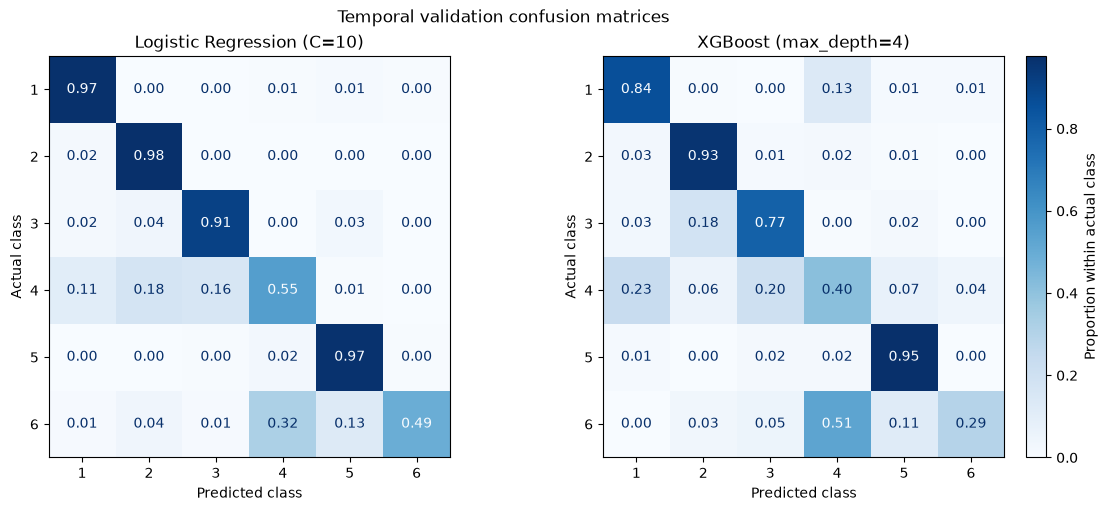

In [136]:
plot_temporal_confusion_matrices(
    selected_temporal_predictions,
    temporal_labels,
)


The pooled confusion matrix shows that temporal errors are highly class-dependent rather than uniformly distributed across gases. Classes 1, 2, 3, and 5 remain well recognized, with recalls above 0.90, whereas classes 4 and 6 are substantially more difficult. Class 4 reaches only 0.55 recall and is confused with several other classes, particularly classes 2 and 3. Class 6 reaches 0.49 recall and is most frequently confused with class 4. This indicates that the loss of temporal performance is driven largely by a small subset of classes whose feature distributions appear less stable across acquisition periods.

Because predictions are pooled across batches, this matrix summarizes overall confusion patterns but does not capture batch-specific variation, which is analyzed separately through the per-batch F1 results.